# 🧪 ElectioAnalytics — Test du Dataset ML Final
**Objectif :** Vérifier la qualité et la cohérence du dataset avant le preprocessing ML  
**Fichier testé :** `data/final/dataset_ml_final.csv`  
**Étapes :**
1. Chargement & structure
2. Valeurs manquantes
3. Distribution des variables cibles
4. Statistiques descriptives des features socio-éco
5. Corrélations avec la variable cible
6. Cohérence temporelle (2017 vs 2022)
7. Détection des outliers
8. Bilan final

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# Style global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('✅ Imports OK')

✅ Imports OK


---
## Étape 1 — Chargement & Structure

In [2]:
df = pd.read_csv('data/final/dataset_ml_final.csv', dtype={'code_geo': str, 'code_commune': str})

print(f'📐 Dimensions      : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'📅 Années          : {sorted(df["annee"].unique())}')
print(f'🏙️  Communes uniques : {df["code_geo"].nunique()}')
print(f'\n📋 Colonnes disponibles :')
for i, col in enumerate(df.columns, 1):
    print(f'   {i:>2}. {col}')

📐 Dimensions      : 1296 lignes × 38 colonnes
📅 Années          : [np.int64(2017), np.int64(2022)]
🏙️  Communes uniques : 648

📋 Colonnes disponibles :
    1. code_geo
    2. code_commune
    3. libelle_commune
    4. annee
    5. inscrits
    6. abstentions
    7. votants
    8. exprimes
    9. pct_abstention
   10. nom_cand1
   11. nom_cand2
   12. nom_cand3
   13. nom_cand4
   14. nom_cand5
   15. pct_cand1
   16. pct_cand2
   17. pct_cand3
   18. pct_cand4
   19. pct_cand5
   20. bloc_cand1
   21. bloc_cand2
   22. bloc_cand3
   23. bloc_cand4
   24. bloc_cand5
   25. pct_CENTRE
   26. pct_DIVERS
   27. pct_DROITE
   28. pct_GAUCHE
   29. taux_chomage
   30. revenu_median
   31. taux_faible_diplome
   32. taux_delinquance
   33. nb_faits_total
   34. population_municipale
   35. population_totale
   36. bloc_vainqueur
   37. cible_binaire
   38. nom_vainqueur


In [3]:
# Aperçu des premières lignes
display(df.head(5))

,code_geo,code_commune,libelle_commune,annee,inscrits,abstentions,votants,exprimes,pct_abstention,nom_cand1,...,taux_chomage,revenu_median,taux_faible_diplome,taux_delinquance,nb_faits_total,population_municipale,population_totale,bloc_vainqueur,cible_binaire,nom_vainqueur
0,59001,00001,Abancourt,2017,358,42,316,311,11.73,LE PEN,...,9.09,22772.0,53.61,0.00,0.0,461,474,DROITE,0,LE PEN
1,59002,00002,Abscon,2017,2805,557,2248,2188,19.86,LE PEN,...,20.42,17482.0,51.20,41.22,183.0,4440,4475,DROITE,0,LE PEN
2,59003,00003,Aibes,2017,249,40,209,204,16.06,LE PEN,...,3.23,17514.0,43.98,0.00,0.0,374,380,DROITE,0,LE PEN
3,59004,00004,Aix,2017,877,74,803,791,8.44,FILLON,...,3.85,25532.0,58.73,0.00,0.0,1185,1199,DROITE,0,FILLON
4,59005,00005,Allennes-les-Marais,2017,2744,435,2309,2249,15.85,LE PEN,...,9.38,22985.0,58.76,14.15,49.0,3462,3508,DROITE,0,LE PEN


In [4]:
# Types de données
print('📋 Types de données :')
display(df.dtypes.to_frame(name='dtype'))

📋 Types de données :


,dtype
code_geo,str
code_commune,str
libelle_commune,str
annee,int64
inscrits,int64
abstentions,int64
votants,int64
exprimes,int64
pct_abstention,float64
nom_cand1,str


---
## Étape 2 — Valeurs Manquantes

In [5]:
nan_total = df.isnull().sum().sum()
print(f'🔍 NaN totaux dans le dataset : {nan_total}')

nan_par_col = df.isnull().sum()
nan_par_col = nan_par_col[nan_par_col > 0]

if len(nan_par_col) == 0:
    print('✅ Aucun NaN détecté — dataset complet')
else:
    print(f'⚠️  {len(nan_par_col)} colonnes avec NaN :')
    display(nan_par_col.to_frame(name='nb_nan'))

🔍 NaN totaux dans le dataset : 0
✅ Aucun NaN détecté — dataset complet


In [6]:
# Couverture par année
features_socioeco = [
    'taux_chomage', 'revenu_median', 'taux_faible_diplome',
    'taux_delinquance', 'population_municipale'
]

print('📊 Couverture par année (communes avec toutes les features socio-éco) :')
for annee in [2017, 2022]:
    sub = df[df['annee'] == annee]
    complet = sub[features_socioeco].notna().all(axis=1).sum()
    print(f'   {annee} : {complet}/{len(sub)} communes ({complet/len(sub)*100:.1f}%)')

📊 Couverture par année (communes avec toutes les features socio-éco) :
   2017 : 648/648 communes (100.0%)
   2022 : 648/648 communes (100.0%)


---
## Étape 3 — Distribution des Variables Cibles

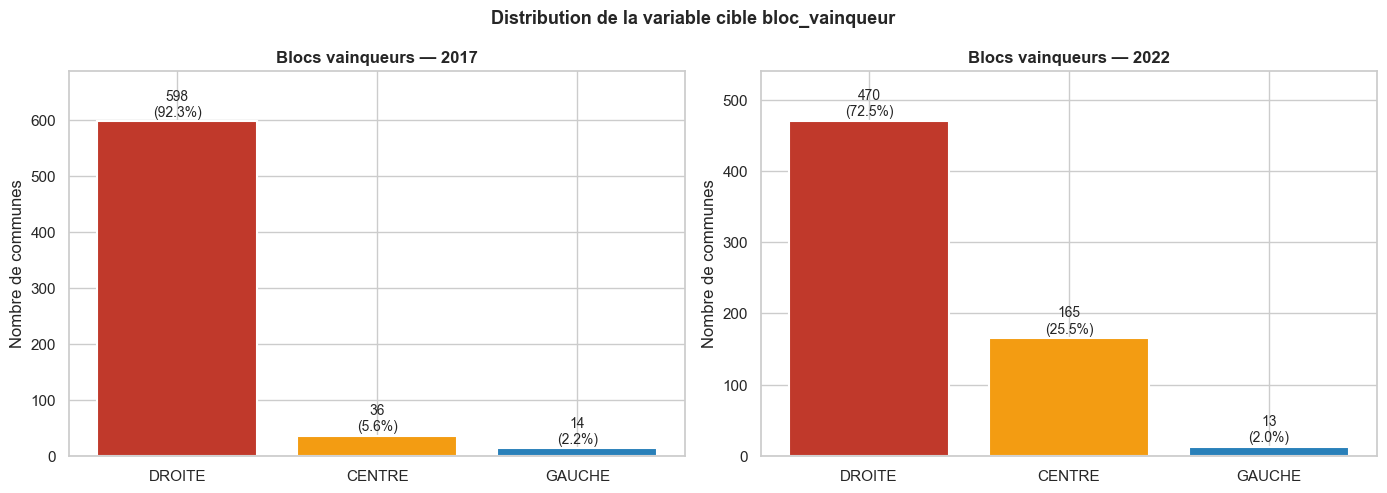

In [7]:
# Distribution bloc_vainqueur
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
couleurs = {'DROITE': '#c0392b', 'CENTRE': '#f39c12', 'GAUCHE': '#2980b9', 'DIVERS': '#7f8c8d'}

for ax, annee in zip(axes, [2017, 2022]):
    sub   = df[df['annee'] == annee]
    counts = sub['bloc_vainqueur'].value_counts()
    colors = [couleurs.get(b, '#95a5a6') for b in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f'{val}\n({val/len(sub)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
    ax.set_title(f'Blocs vainqueurs — {annee}', fontweight='bold')
    ax.set_ylabel('Nombre de communes')
    ax.set_ylim(0, max(counts.values) * 1.15)

plt.suptitle('Distribution de la variable cible bloc_vainqueur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Distribution cible_binaire
print('📊 Distribution cible_binaire (0=DROITE / 1=EXCEPTION) :')
for annee in [2017, 2022]:
    sub = df[df['annee'] == annee]
    n0  = (sub['cible_binaire'] == 0).sum()
    n1  = (sub['cible_binaire'] == 1).sum()
    ratio = n0 / n1 if n1 > 0 else float('inf')
    print(f'   {annee} : DROITE={n0} ({n0/len(sub)*100:.1f}%) | EXCEPTION={n1} ({n1/len(sub)*100:.1f}%) | ratio={ratio:.1f}:1')

📊 Distribution cible_binaire (0=DROITE / 1=EXCEPTION) :
   2017 : DROITE=598 (92.3%) | EXCEPTION=50 (7.7%) | ratio=12.0:1
   2022 : DROITE=470 (72.5%) | EXCEPTION=178 (27.5%) | ratio=2.6:1


In [9]:
# Évolution commune par commune 2017→2022
df_2017 = df[df['annee'] == 2017][['code_geo', 'bloc_vainqueur']].rename(columns={'bloc_vainqueur': 'bloc_2017'})
df_2022 = df[df['annee'] == 2022][['code_geo', 'bloc_vainqueur']].rename(columns={'bloc_vainqueur': 'bloc_2022'})
df_evol = df_2017.merge(df_2022, on='code_geo')

print('📊 Matrice de transition blocs 2017 → 2022 (nombre de communes) :')
pivot_transition = pd.crosstab(df_evol['bloc_2017'], df_evol['bloc_2022'],
                                rownames=['2017 →'], colnames=['→ 2022'])
display(pivot_transition)

# Communes qui ont basculé
bascules = df_evol[df_evol['bloc_2017'] != df_evol['bloc_2022']]
print(f'\n🔄 Communes ayant changé de bloc : {len(bascules)}/{len(df_evol)} ({len(bascules)/len(df_evol)*100:.1f}%)')

📊 Matrice de transition blocs 2017 → 2022 (nombre de communes) :


→ 2022,CENTRE,DROITE,GAUCHE
2017 →,,,
CENTRE,35,0,1
DROITE,130,466,2
GAUCHE,0,4,10



🔄 Communes ayant changé de bloc : 137/648 (21.1%)


---
## Étape 4 — Statistiques Descriptives des Features Socio-éco

In [10]:
print('📊 Statistiques descriptives des features socio-éco par année :')
for annee in [2017, 2022]:
    print(f'\n── {annee} ──')
    display(df[df['annee'] == annee][features_socioeco].describe().round(2))

📊 Statistiques descriptives des features socio-éco par année :

── 2017 ──


,taux_chomage,revenu_median,taux_faible_diplome,taux_delinquance,population_municipale
count,648.00,648.00,648.00,648.00,648.00
mean,13.67,20919.65,55.67,15.63,4018.09
std,6.77,3047.55,5.17,36.48,12346.60
min,1.27,13298.00,38.46,0.00,40.00
25%,8.84,18813.75,52.11,0.00,577.75
50%,12.73,20770.00,55.22,6.11,1311.50
75%,17.73,22749.75,58.68,23.69,3152.25
max,47.37,34671.00,76.58,798.68,232440.00



── 2022 ──


,taux_chomage,revenu_median,taux_faible_diplome,taux_delinquance,population_municipale
count,648.00,648.00,648.00,648.00,648.00
mean,11.11,23276.28,55.17,14.52,4029.77
std,6.29,3386.21,6.11,34.10,12492.65
min,0.00,14580.00,37.00,0.00,40.00
25%,6.50,20980.00,50.91,0.00,589.25
50%,9.88,23030.00,53.95,3.24,1339.00
75%,15.00,25292.50,58.59,21.16,3174.75
max,36.93,37210.00,79.12,602.32,236710.00


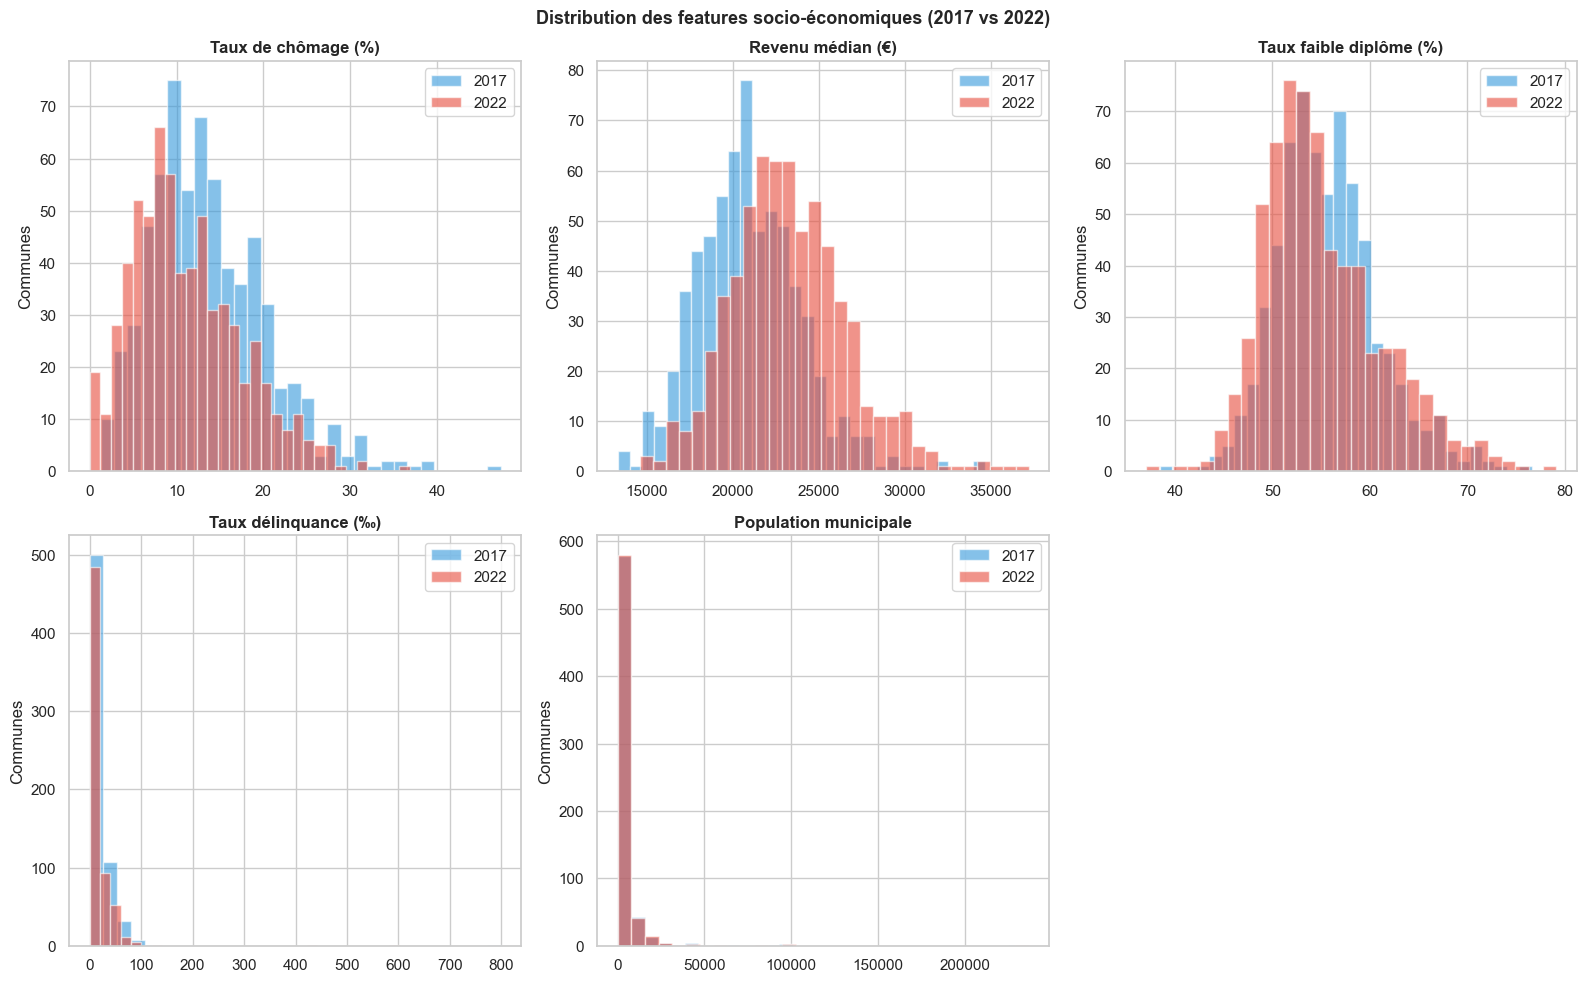

In [11]:
# Distributions des features socio-éco
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

features_plot = features_socioeco + ['taux_delinquance']
labels = {
    'taux_chomage':        'Taux de chômage (%)',
    'revenu_median':       'Revenu médian (€)',
    'taux_faible_diplome': 'Taux faible diplôme (%)',
    'taux_delinquance':    'Taux délinquance (‰)',
    'population_municipale': 'Population municipale'
}

for ax, feat in zip(axes, features_socioeco):
    for annee, color in [(2017, '#3498db'), (2022, '#e74c3c')]:
        sub = df[df['annee'] == annee][feat].dropna()
        ax.hist(sub, bins=30, alpha=0.6, color=color, label=str(annee), edgecolor='white')
    ax.set_title(labels.get(feat, feat), fontweight='bold')
    ax.legend()
    ax.set_ylabel('Communes')

# Cacher le 6e subplot vide
axes[-1].set_visible(False)

plt.suptitle('Distribution des features socio-économiques (2017 vs 2022)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Étape 5 — Corrélations avec la Variable Cible

In [12]:
# Corrélation de Pearson entre les features numériques et cible_binaire
features_ml = features_socioeco + ['pct_abstention', 'inscrits']

print('📊 Corrélations avec cible_binaire (Pearson) :')
for annee in [2017, 2022]:
    sub = df[df['annee'] == annee]
    corrs = sub[features_ml + ['cible_binaire']].corr()['cible_binaire'].drop('cible_binaire')
    corrs = corrs.sort_values(key=abs, ascending=False)
    print(f'\n── {annee} ──')
    for feat, val in corrs.items():
        barre = '█' * int(abs(val) * 20)
        signe = '+' if val > 0 else '-'
        print(f'   {feat:<30} : {signe}{abs(val):.3f}  {barre}')

📊 Corrélations avec cible_binaire (Pearson) :

── 2017 ──
   taux_faible_diplome            : +0.345  ██████
   population_municipale          : +0.258  █████
   inscrits                       : +0.256  █████
   revenu_median                  : +0.160  ███
   taux_delinquance               : +0.137  ██
   taux_chomage                   : -0.036  
   pct_abstention                 : +0.008  

── 2022 ──
   taux_faible_diplome            : +0.663  █████████████
   revenu_median                  : +0.567  ███████████
   taux_chomage                   : -0.302  ██████
   pct_abstention                 : -0.239  ████
   inscrits                       : +0.153  ███
   population_municipale          : +0.148  ██
   taux_delinquance               : +0.095  █


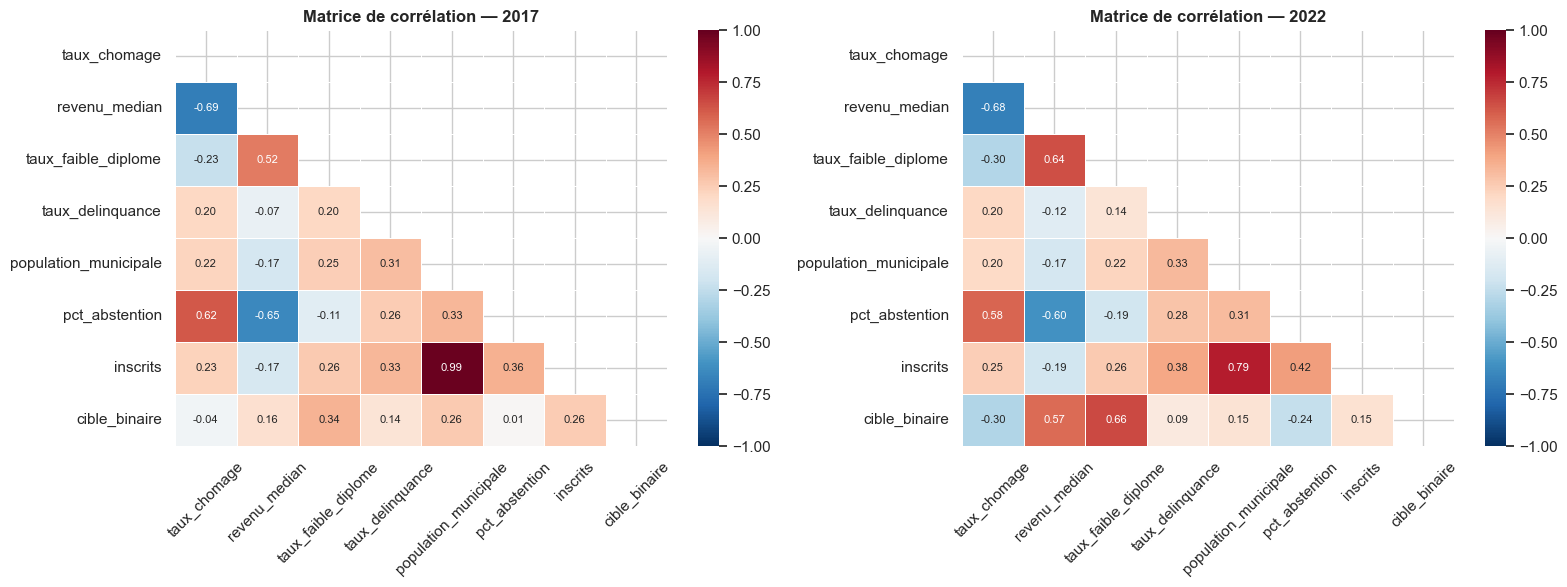

In [13]:
# Heatmap de corrélation — toutes features numériques
cols_corr = features_ml + ['cible_binaire']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, annee in zip(axes, [2017, 2022]):
    sub    = df[df['annee'] == annee][cols_corr]
    corr_m = sub.corr()
    mask   = np.triu(np.ones_like(corr_m, dtype=bool))
    sns.heatmap(corr_m, ax=ax, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                linewidths=0.5, annot_kws={'size': 8})
    ax.set_title(f'Matrice de corrélation — {annee}', fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_54756\4166893859.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=ordre, patch_artist=True)
C:\Users\user\AppData\Local\Temp\ipykernel_54756\4166893859.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=ordre, patch_artist=True)
C:\Users\user\AppData\Local\Temp\ipykernel_54756\4166893859.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=ordre, patch_artist=True)
C:\Users\user\AppData\Local\Temp\ipykernel_54756\4166893859.py:12: MatplotlibDeprecationWarning: The 'labels' parameter o

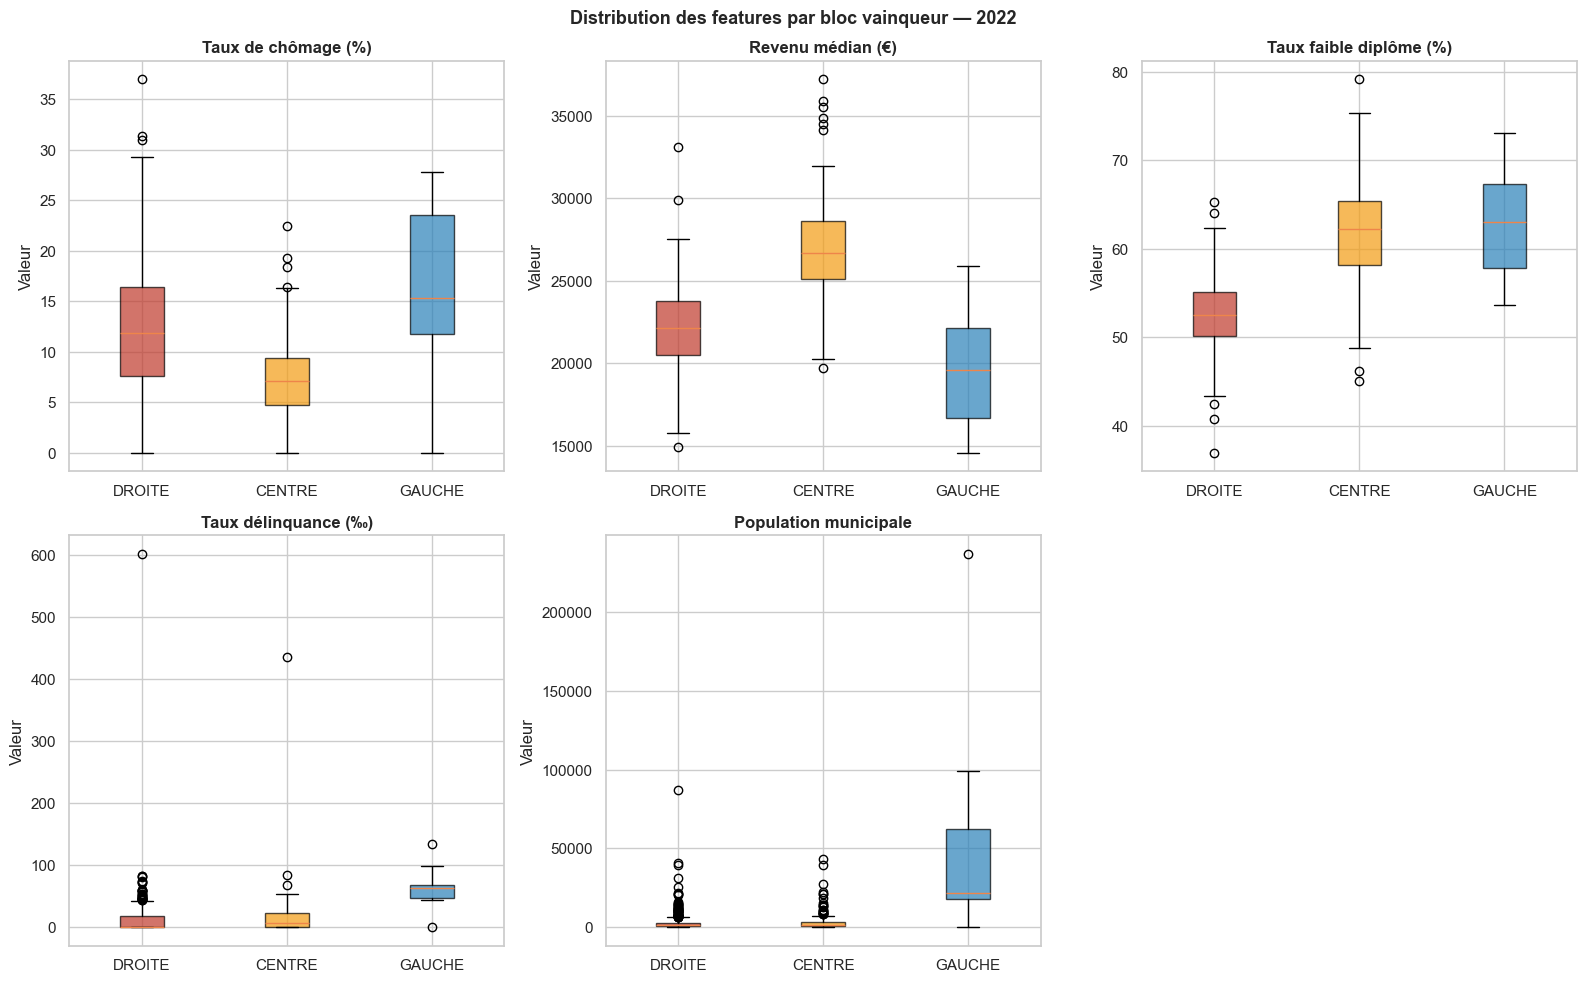

In [14]:
# Boxplots : distribution des features par bloc vainqueur
df_plot = df[df['annee'] == 2022].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
couleurs_bloc = {'DROITE': '#c0392b', 'CENTRE': '#f39c12', 'GAUCHE': '#2980b9', 'DIVERS': '#7f8c8d'}

for ax, feat in zip(axes, features_socioeco):
    ordre  = ['DROITE', 'CENTRE', 'GAUCHE']
    colors = [couleurs_bloc[b] for b in ordre]
    data   = [df_plot[df_plot['bloc_vainqueur'] == b][feat].dropna() for b in ordre]
    bp = ax.boxplot(data, labels=ordre, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(labels.get(feat, feat), fontweight='bold')
    ax.set_ylabel('Valeur')

axes[-1].set_visible(False)
plt.suptitle('Distribution des features par bloc vainqueur — 2022', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Étape 6 — Cohérence Temporelle (2017 vs 2022)

In [15]:
# Évolution des features socio-éco entre 2017 et 2022
df_2017s = df[df['annee'] == 2017][['code_geo'] + features_socioeco].add_suffix('_2017').rename(columns={'code_geo_2017': 'code_geo'})
df_2022s = df[df['annee'] == 2022][['code_geo'] + features_socioeco].add_suffix('_2022').rename(columns={'code_geo_2022': 'code_geo'})
df_compare = df_2017s.merge(df_2022s, on='code_geo')

print('📊 Évolution moyenne des features socio-éco (2017 → 2022) :')
print(f'   {"Feature":<30} {"Moy 2017":>12} {"Moy 2022":>12} {"Évolution":>12}')
print('-' * 70)
for feat in features_socioeco:
    m17 = df_compare[f'{feat}_2017'].mean()
    m22 = df_compare[f'{feat}_2022'].mean()
    evol = m22 - m17
    fleche = '↑' if evol > 0 else '↓'
    print(f'   {feat:<30} {m17:>12.2f} {m22:>12.2f} {fleche} {abs(evol):>8.2f}')

📊 Évolution moyenne des features socio-éco (2017 → 2022) :
   Feature                            Moy 2017     Moy 2022    Évolution
----------------------------------------------------------------------
   taux_chomage                          13.67        11.11 ↓     2.56
   revenu_median                      20919.65     23276.28 ↑  2356.63
   taux_faible_diplome                   55.67        55.17 ↓     0.51
   taux_delinquance                      15.63        14.52 ↓     1.11
   population_municipale               4018.09      4029.77 ↑    11.68


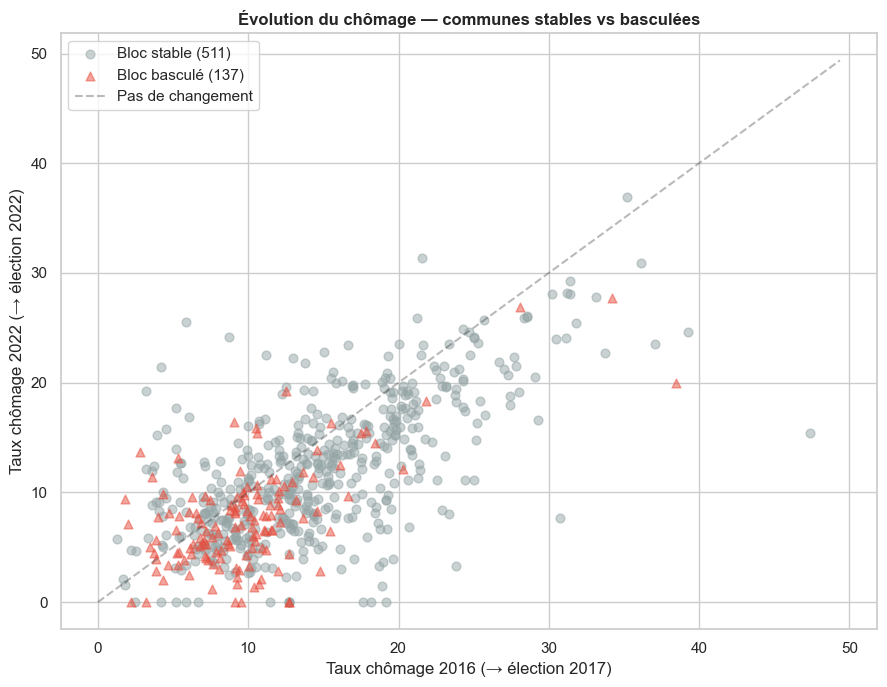

In [16]:
# Scatter : chômage 2017 vs chômage 2022 coloré par bascule
df_evol2 = df_evol.merge(df_compare, on='code_geo')
df_evol2['bascule'] = df_evol2['bloc_2017'] != df_evol2['bloc_2022']

fig, ax = plt.subplots(figsize=(9, 7))
for bascule, label, color, marker in [
    (False, 'Bloc stable',  '#95a5a6', 'o'),
    (True,  'Bloc basculé', '#e74c3c', '^')
]:
    sub = df_evol2[df_evol2['bascule'] == bascule]
    ax.scatter(sub['taux_chomage_2017'], sub['taux_chomage_2022'],
               alpha=0.5, label=f'{label} ({len(sub)})', color=color, marker=marker, s=40)

# Ligne diagonale (pas de changement)
lim = max(df_evol2['taux_chomage_2017'].max(), df_evol2['taux_chomage_2022'].max()) + 2
ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, label='Pas de changement')
ax.set_xlabel('Taux chômage 2016 (→ élection 2017)')
ax.set_ylabel('Taux chômage 2022 (→ élection 2022)')
ax.set_title('Évolution du chômage — communes stables vs basculées', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## Étape 7 — Détection des Outliers

In [17]:
# Méthode IQR : valeurs au-delà de Q1-1.5*IQR ou Q3+1.5*IQR
print('📊 Détection des outliers (méthode IQR) par feature et par année :')
print(f'   {"Feature":<30} {"2017 outliers":>15} {"2022 outliers":>15}')
print('-' * 65)

for feat in features_socioeco:
    counts = []
    for annee in [2017, 2022]:
        sub  = df[df['annee'] == annee][feat].dropna()
        Q1, Q3 = sub.quantile(0.25), sub.quantile(0.75)
        IQR  = Q3 - Q1
        n_out = ((sub < Q1 - 1.5 * IQR) | (sub > Q3 + 1.5 * IQR)).sum()
        counts.append(f'{n_out} ({n_out/len(sub)*100:.1f}%)')
    print(f'   {feat:<30} {counts[0]:>15} {counts[1]:>15}')

📊 Détection des outliers (méthode IQR) par feature et par année :
   Feature                          2017 outliers   2022 outliers
-----------------------------------------------------------------
   taux_chomage                         14 (2.2%)        8 (1.2%)
   revenu_median                        10 (1.5%)        9 (1.4%)
   taux_faible_diplome                  12 (1.9%)       16 (2.5%)
   taux_delinquance                     18 (2.8%)       28 (4.3%)
   population_municipale               77 (11.9%)      76 (11.7%)


In [18]:
# Top 5 outliers population (communes très peuplées)
print('📊 Top 10 communes par population municipale (2022) :')
top_pop = df[df['annee'] == 2022].nlargest(10, 'population_municipale')[[
    'libelle_commune', 'population_municipale', 'bloc_vainqueur',
    'taux_chomage', 'revenu_median'
]]
display(top_pop)

📊 Top 10 communes par population municipale (2022) :


,libelle_commune,population_municipale,bloc_vainqueur,taux_chomage,revenu_median
649,Lille,236710,GAUCHE,15.26,20520.0
839,Tourcoing,99011,GAUCHE,18.23,18300.0
832,Roubaix,98892,GAUCHE,25.47,14580.0
966,Dunkerque,86788,DROITE,18.33,20240.0
651,Villeneuve-d'Ascq,62067,GAUCHE,15.37,22000.0
1294,Valenciennes,42991,CENTRE,18.34,20250.0
835,Wattrelos,40836,DROITE,15.70,19450.0
1110,Douai,39648,DROITE,21.29,18440.0
837,Marcq-en-Baroeul,39356,CENTRE,8.52,29490.0
1144,Cambrai,31425,DROITE,20.16,19620.0


In [19]:
# Top 5 taux de chômage (communes les plus touchées)
print('📊 Top 10 communes avec le plus fort taux de chômage (2022) :')
top_chom = df[df['annee'] == 2022].nlargest(10, 'taux_chomage')[[
    'libelle_commune', 'taux_chomage', 'revenu_median',
    'population_municipale', 'bloc_vainqueur'
]]
display(top_chom)

📊 Top 10 communes avec le plus fort taux de chômage (2022) :


,libelle_commune,taux_chomage,revenu_median,population_municipale,bloc_vainqueur
660,Avesnes-sur-Helpe,36.93,15750.0,4118,DROITE
939,Sains-du-Nord,31.35,18400.0,2779,DROITE
1219,Denain,30.92,14890.0,20640,DROITE
702,Jeumont,29.29,16910.0,10342,DROITE
695,Fourmies,28.18,16810.0,11456,DROITE
1146,Le Cateau-Cambrésis,28.12,16820.0,6929,DROITE
1278,Condé-sur-l'Escaut,28.12,16620.0,9396,DROITE
905,Hautmont,27.79,16280.0,14182,DROITE
709,Maubeuge,27.75,16320.0,29066,GAUCHE
1101,Waziers,26.89,16770.0,7354,DROITE


---
## Étape 8 — Bilan Final

In [20]:
print('=' * 60)
print('📋 BILAN FINAL DU DATASET ML')
print('=' * 60)

print(f"""
✅ Structure
   Lignes          : {len(df)}
   Colonnes        : {df.shape[1]}
   Communes        : {df['code_geo'].nunique()}
   Années          : 2017 (train) + 2022 (test)

✅ Qualité
   NaN résiduels   : {df.isnull().sum().sum()}
   Couverture 2017 : {df[df['annee']==2017][features_socioeco].notna().all(axis=1).sum()}/648
   Couverture 2022 : {df[df['annee']==2022][features_socioeco].notna().all(axis=1).sum()}/648

✅ Variable cible (bloc_vainqueur)
   2017 : DROITE={( df[df['annee']==2017]['bloc_vainqueur']=='DROITE').sum()}  CENTRE={(df[df['annee']==2017]['bloc_vainqueur']=='CENTRE').sum()}  GAUCHE={(df[df['annee']==2017]['bloc_vainqueur']=='GAUCHE').sum()}
   2022 : DROITE={(df[df['annee']==2022]['bloc_vainqueur']=='DROITE').sum()}  CENTRE={(df[df['annee']==2022]['bloc_vainqueur']=='CENTRE').sum()}  GAUCHE={(df[df['annee']==2022]['bloc_vainqueur']=='GAUCHE').sum()}

✅ Communes ayant changé de bloc (2017→2022)
   {len(bascules)} communes ({len(bascules)/len(df_evol)*100:.1f}%)

⚠️  Points d'attention pour le ML
   - Déséquilibre classe important en 2017 (DROITE=92.3%)
   - Utiliser class_weight='balanced' dans les modèles
   - Population : outliers majeurs (Lille ~230k vs médiane ~800)
     → envisager log-transform pour population
   - GAUCHE trop rare (13-14 communes) pour modéliser seul
     → fusionner GAUCHE+DIVERS en NON-DROITE pour binaire
""")

print('\n🚀 Prochaine étape : preprocessing.py')
print('   → Encodage des blocs candidats')
print('   → StandardScaler sur features numériques')
print('   → Log-transform sur population')
print('   → Sélection de features')

📋 BILAN FINAL DU DATASET ML

✅ Structure
   Lignes          : 1296
   Colonnes        : 38
   Communes        : 648
   Années          : 2017 (train) + 2022 (test)

✅ Qualité
   NaN résiduels   : 0
   Couverture 2017 : 648/648
   Couverture 2022 : 648/648

✅ Variable cible (bloc_vainqueur)
   2017 : DROITE=598  CENTRE=36  GAUCHE=14
   2022 : DROITE=470  CENTRE=165  GAUCHE=13

✅ Communes ayant changé de bloc (2017→2022)
   137 communes (21.1%)

⚠️  Points d'attention pour le ML
   - Déséquilibre classe important en 2017 (DROITE=92.3%)
   - Utiliser class_weight='balanced' dans les modèles
   - Population : outliers majeurs (Lille ~230k vs médiane ~800)
     → envisager log-transform pour population
   - GAUCHE trop rare (13-14 communes) pour modéliser seul
     → fusionner GAUCHE+DIVERS en NON-DROITE pour binaire


🚀 Prochaine étape : preprocessing.py
   → Encodage des blocs candidats
   → StandardScaler sur features numériques
   → Log-transform sur population
   → Sélection de feature